In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [35]:
df = pd.read_csv('newborns_stats.csv', sep = ',')
df.head()

,year,month,c1,cat1,target
0,2015,1,NaN,0,12346
1,2015,2,NaN,0,11210
2,2015,3,40.045,0,12237
3,2015,4,39.860,0,12685
4,2015,5,42.367,1,12881


In [36]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df.set_index('date', inplace = True)
df.sort_index(inplace=True)
df = df.asfreq('MS')
df = df[['target', 'c1', 'cat1']]
df.head()

,target,c1,cat1
date,,,
2015-01-01,12346,NaN,0
2015-02-01,11210,NaN,0
2015-03-01,12237,40.045,0
2015-04-01,12685,39.860,0
2015-05-01,12881,42.367,1


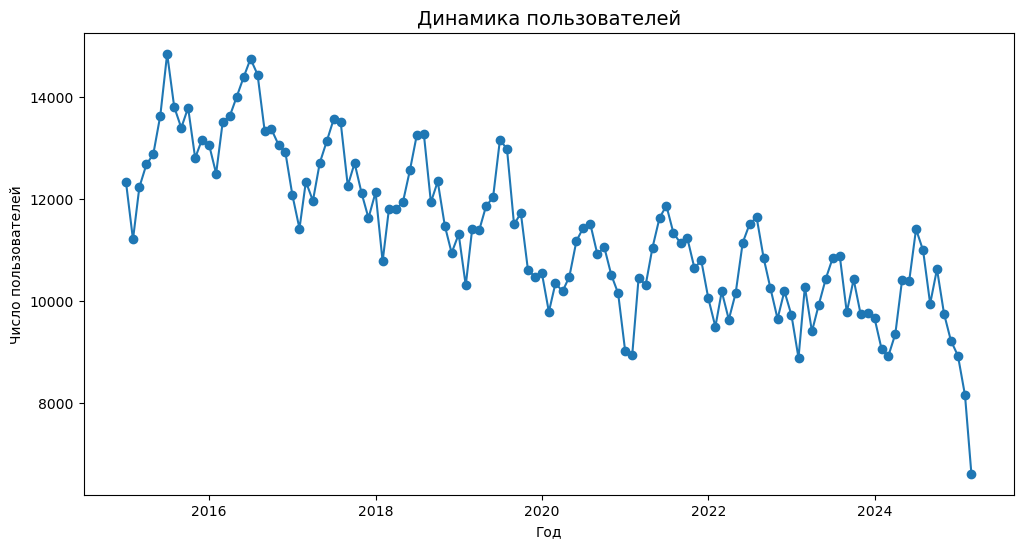

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['target'], marker = 'o')

plt.title('Динамика пользователей', fontsize = 14)
plt.xlabel('Год')
plt.ylabel('Число пользователей')
plt.show()

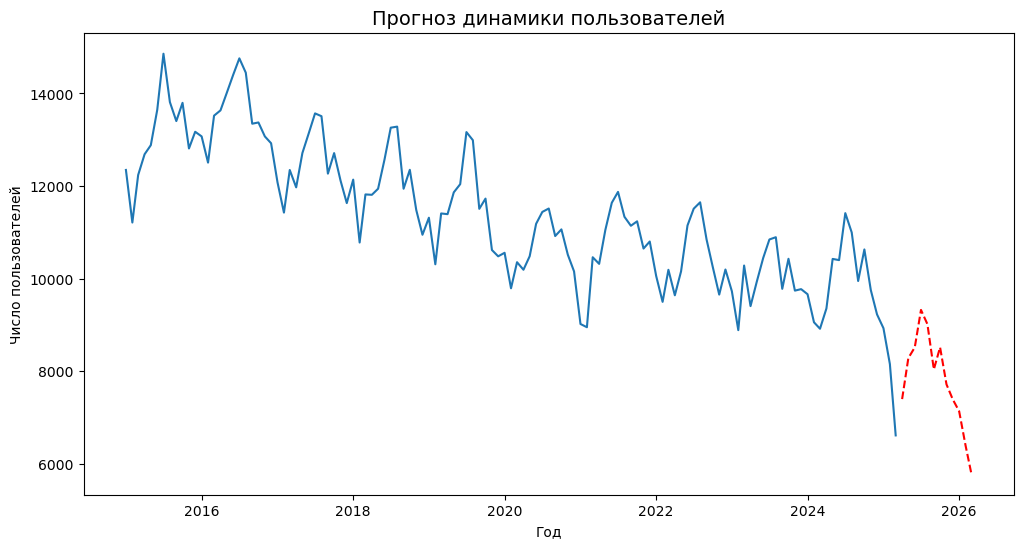

In [38]:
model = SARIMAX(df['target'], order = (1, 1, 1), seasonal_order = (1, 1, 1, 12))
model_fitted = model.fit()

forecast = model_fitted.forecast(steps=12)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['target'])
plt.plot(forecast.index, forecast, color='red', linestyle='--')
plt.title('Прогноз динамики пользователей', fontsize = 14)
plt.xlabel('Год')
plt.ylabel('Число пользователей')
plt.show()

In [39]:
df_forecast = pd.DataFrame(forecast)
df_forecast.columns = ['Прогноз (Кол-во пользователей)']
display(df_forecast.round(0).astype(int))

,Прогноз (Кол-во пользователей)
2025-04-01,7396
2025-05-01,8281
2025-06-01,8513
2025-07-01,9322
2025-08-01,9014
2025-09-01,8037
2025-10-01,8515
2025-11-01,7714
2025-12-01,7392
2026-01-01,7132
